# 03 · EDA — Headline KPIs and Time Analysis

**Phases 4 and 6 of the brief.**

Two jobs here. First, establish the handful of numbers that every later statement is
measured against — if we don't know the overall reorder rate, we can't say a department's
reorder rate is "high". Second, answer *when* customers buy.

Every chart below exists to answer a stated question. Where a question turned out to have
a boring answer, that is reported too — a flat line is a finding.

In [1]:
import sys, pathlib, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import instacart as ic, analysis as an
plt = ic.set_style()
pd.set_option("display.width", 170, "display.max_columns", 40)

orders = ic.load_clean("orders_clean")
customers = ic.load_clean("customers")
prods, aisles, depts = ic.load_lookups()
items = ic.load_clean("order_items", columns=["order_id","user_id","product_uid","reordered",
                                              "add_to_cart_order","order_number","order_dow",
                                              "order_hour_of_day","department_id","aisle_id"])
known = orders[orders.has_basket_data]
print(f"orders {len(orders):,} | with contents {len(known):,} | basket lines {len(items):,} | customers {len(customers):,}")

orders 3,421,083 | with contents 3,346,083 | basket lines 33,819,106 | customers 206,209


## 3.1 Phase 4 — Overall KPIs

Two bases are used throughout this project and they are always named:

* **all orders (3,421,083)** — for anything derived from order timing, which is populated
  for every order including the `test` holdout;
* **orders with contents (3,346,083)** — for anything derived from what was in the basket.

In [2]:
kpi = an.overall_kpis(orders, items, prods, customers)
ic.savetable(kpi, "kpi_overall")
display(kpi.style.format({"value": "{:,.2f}"}).hide(axis="index"))

  table  -> reports/tables/kpi_overall.csv  (14 rows)


kpi,value,definition
Total customers,"206,209.00",distinct user_id in orders
Total orders (all),"3,421,083.00","every order row, incl. 75,000 test orders with no contents"
Total orders (with basket contents),"3,346,083.00",prior + train; the base for all item-level analysis
Total items purchased,"33,819,106.00",basket lines = product x order
Products in catalogue,"49,688.00",products.csv rows
Products ever purchased,"49,573.00",distinct analytical products with >=1 purchase
Average basket size,10.11,items per order
Median basket size,8.00,items per order
Average orders per customer,16.59,all orders / customers
Median orders per customer,10.00,per-customer order count


### The five numbers that matter

| KPI | Value | Why it is the benchmark |
|---|---|---|
| Customers | **206,209** | denominator for every per-customer statement |
| Items purchased | **33,819,106** | across 3.35M baskets |
| Average basket | **10.1 items** (median 8) | a department is "big" relative to this |
| Orders per customer | **16.6** (median 10) | the mean is inflated by a long tail; the median is the typical customer |
| **Reorder rate** | **59.0%** (62.9% excluding first orders) | the single most important number in this dataset |

**Nearly six in every ten items sold are something that customer has bought before.**
That one figure reframes the whole business: Instacart is not primarily a discovery
platform, it is a replenishment platform. Everything in notebooks 05 and 06 is an attempt
to explain and exploit that number.

findfont: Failed to find font weight 600 for DejaVu Sans, now using 700.


findfont: Failed to find font weight 600 for DejaVu Sans, now using 700.


  figure -> reports/figures/03_reorder_headline.png


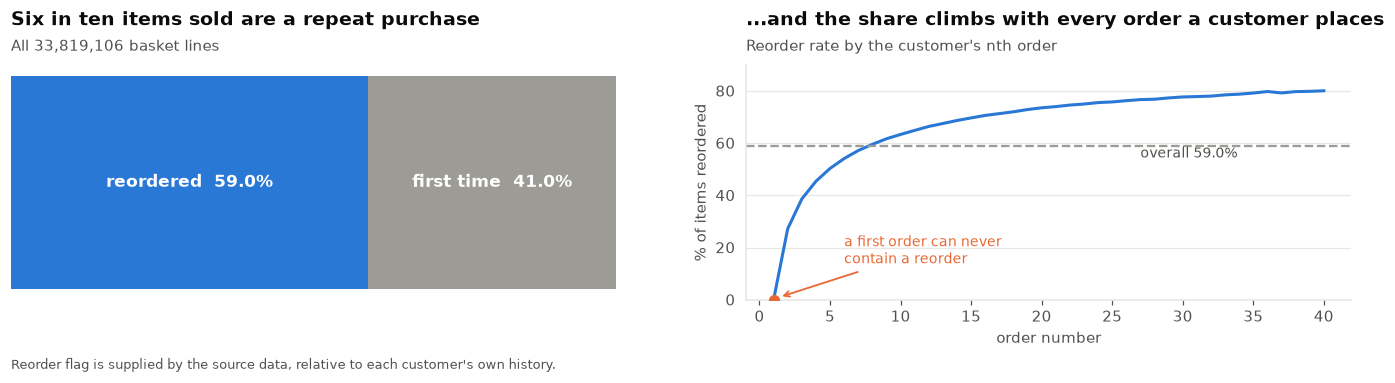

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.6))
r = [items.reordered.mean(), 1-items.reordered.mean()]
axes[0].barh([0], [r[0]*100], color=ic.PALETTE["s1"], height=.5)
axes[0].barh([0], [r[1]*100], left=[r[0]*100], color=ic.PALETTE["neutral"], height=.5)
axes[0].text(r[0]*50, 0, f"reordered  {r[0]*100:.1f}%", ha="center", va="center",
             color="white", fontsize=11, fontweight="600")
axes[0].text(r[0]*100 + r[1]*50, 0, f"first time  {r[1]*100:.1f}%", ha="center", va="center",
             color="white", fontsize=11, fontweight="600")
axes[0].set_yticks([]); axes[0].set_xlim(0,100); axes[0].set_xticks([])
for s in axes[0].spines.values(): s.set_visible(False)
ic.finish(axes[0], "Six in ten items sold are a repeat purchase",
          f"All {len(items):,} basket lines", source="Reorder flag is supplied by the source data, relative to each customer's own history.")

ron = an.reorder_by_order_number(items, cap=40)
axes[1].plot(ron.order_number, ron.reorder_rate*100, color=ic.PALETTE["s1"], lw=2)
axes[1].axhline(items.reordered.mean()*100, color=ic.PALETTE["neutral"], lw=1.5, ls="--")
axes[1].text(27, items.reordered.mean()*100-4.5, "overall 59.0%", color=ic.PALETTE["muted"], fontsize=9)
axes[1].scatter([1], [0], color=ic.PALETTE["s2"], s=40, zorder=5)
axes[1].annotate("a first order can never\ncontain a reorder", xy=(1.4, 1), xytext=(6, 14),
                 fontsize=9, color=ic.PALETTE["s2"],
                 arrowprops=dict(arrowstyle="->", color=ic.PALETTE["s2"], lw=1.2))
ic.finish(axes[1], "...and the share climbs with every order a customer places",
          "Reorder rate by the customer's nth order", "order number", "% of items reordered")
axes[1].set_ylim(0, 90)
fig.tight_layout(); ic.savefig(fig, "03_reorder_headline"); plt.show()

## 3.2 How concentrated is demand?

*Question: do a few products carry the business, or is demand spread across the catalogue?*
This decides whether assortment strategy or long-tail strategy is the right lens.

In [4]:
pk = an.product_kpis(items, prods)
pk_sorted = pk.sort_values("purchases", ascending=False).reset_index(drop=True)
cum = pk_sorted.purchases.cumsum()/pk_sorted.purchases.sum()
n80 = int((cum<=0.8).sum())+1
conc = pd.DataFrame({
    "slice": ["top 10 products","top 100 products","top 1% of products (496)",
              f"top {n80:,} products", "bottom 50% of products"],
    "share of all units sold": [pk_sorted.head(10).purchases.sum()/len(items),
                                pk_sorted.head(100).purchases.sum()/len(items),
                                pk_sorted.head(496).purchases.sum()/len(items),
                                0.80,
                                pk_sorted.tail(len(pk_sorted)//2).purchases.sum()/len(items)],
})
display(conc.style.format({"share of all units sold":"{:.1%}"}).hide(axis="index"))

slice,share of all units sold
top 10 products,7.2%
top 100 products,23.1%
top 1% of products (496),42.7%
"top 4,548 products",80.0%
bottom 50% of products,1.7%


  figure -> reports/figures/03_demand_concentration.png


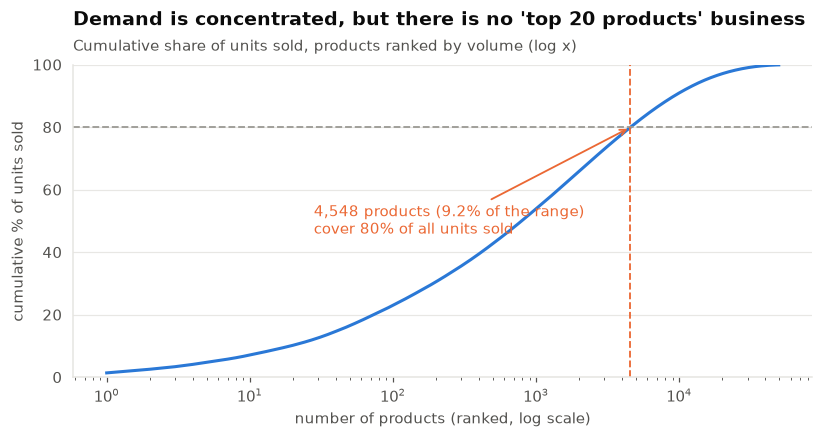

In [5]:
fig, ax = plt.subplots(figsize=(7.6, 4.1))
x = np.arange(1, len(pk_sorted)+1)
ax.plot(x, cum*100, color=ic.PALETTE["s1"], lw=2)
ax.axhline(80, color=ic.PALETTE["neutral"], ls="--", lw=1.2)
ax.axvline(n80, color=ic.PALETTE["s2"], ls="--", lw=1.2)
ax.set_xscale("log")
ax.annotate(f"{n80:,} products (9.2% of the range)\ncover 80% of all units sold",
            xy=(n80, 80), xytext=(28, 46), fontsize=9.5, color=ic.PALETTE["s2"],
            arrowprops=dict(arrowstyle="->", color=ic.PALETTE["s2"], lw=1.2))
ic.finish(ax, "Demand is concentrated, but there is no 'top 20 products' business",
          "Cumulative share of units sold, products ranked by volume (log x)",
          "number of products (ranked, log scale)", "cumulative % of units sold")
ax.set_ylim(0,100)
fig.tight_layout(); ic.savefig(fig, "03_demand_concentration"); plt.show()

**Finding.** The top 100 products out of 49,573 carry **23.1%** of all units, and the top
1% carry **42.7%** — steep concentration. But reaching 80% of volume still takes **4,548
products**. So this is not a business that can be run from a 50-SKU hero list, and it is
also not a flat long tail. The practical read: a few hundred products deserve
individually-managed availability and promotion, while the next several thousand matter in
aggregate for assortment breadth.

## 3.3 Phase 6.1 — Hour of day

*Question: when in the day do orders happen, and does shopping behaviour change with the hour?*

In [6]:
bh = an.by_hour(orders); ic.savetable(bh, "orders_by_hour")
display(bh.round(4))

  table  -> reports/tables/orders_by_hour.csv  (24 rows)


,order_hour_of_day,orders,order_share,avg_basket,reorder_rate
0,0,22758,0.0067,10.2606,0.5657
1,1,12398,0.0036,10.0316,0.5581
2,2,7539,0.0022,9.8522,0.5556
3,3,5474,0.0016,10.0616,0.5605
4,4,5527,0.0016,10.3308,0.5724
5,5,9569,0.0028,9.8047,0.6086
6,6,30529,0.0089,10.1174,0.6370
7,7,91868,0.0269,10.3101,0.6447
8,8,178201,0.0521,10.2331,0.6323
9,9,257812,0.0754,10.1001,0.6196


findfont: Failed to find font weight 600 for DejaVu Sans, now using 700.


  figure -> reports/figures/03_orders_by_hour.png


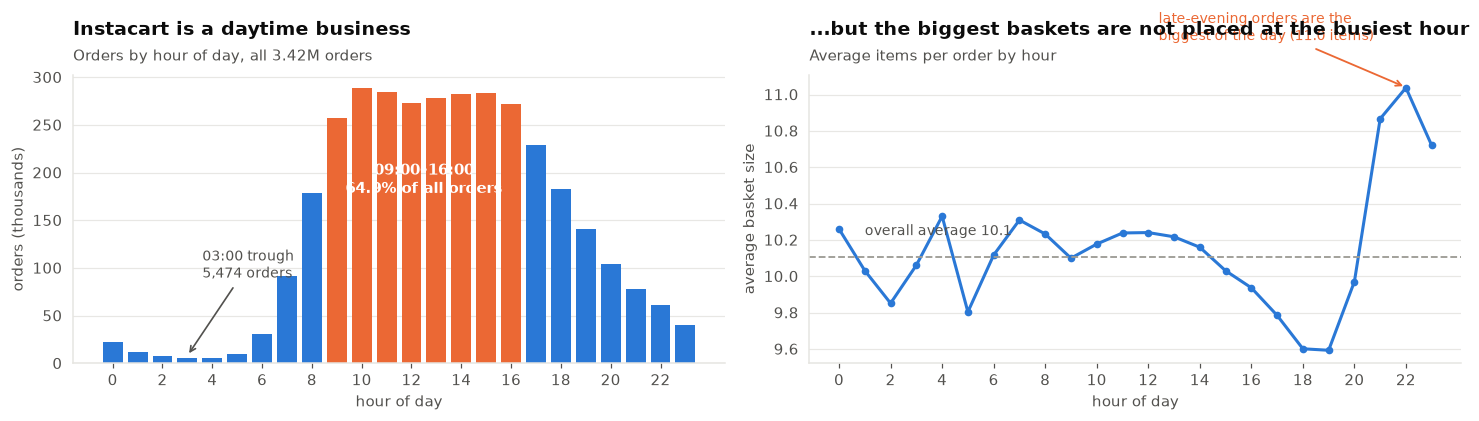

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.0))
peak = bh.orders.idxmax()
colors = [ic.PALETTE["s2"] if 9 <= h <= 16 else ic.PALETTE["s1"] for h in bh.order_hour_of_day]
axes[0].bar(bh.order_hour_of_day, bh.orders/1000, color=colors)
axes[0].text(12.5, bh.orders.max()/1000*0.62, "09:00–16:00\n64.9% of all orders",
             ha="center", fontsize=10, color="white", fontweight="600")
axes[0].annotate("03:00 trough\n5,474 orders", xy=(3, 8), xytext=(3.6, 90), fontsize=9,
                 color=ic.PALETTE["muted"], arrowprops=dict(arrowstyle="->", color=ic.PALETTE["muted"], lw=1.1))
ic.finish(axes[0], "Instacart is a daytime business",
          "Orders by hour of day, all 3.42M orders", "hour of day", "orders (thousands)")
axes[0].set_xticks(range(0,24,2))

axes[1].plot(bh.order_hour_of_day, bh.avg_basket, color=ic.PALETTE["s1"], lw=2, marker="o", ms=4)
axes[1].axhline(known.basket_size.mean(), color=ic.PALETTE["neutral"], ls="--", lw=1.2)
axes[1].text(1, known.basket_size.mean()+.12, "overall average 10.1", color=ic.PALETTE["muted"], fontsize=9)
axes[1].annotate("late-evening orders are the\nbiggest of the day (11.0 items)",
                 xy=(22, 11.04), xytext=(12.4, 11.3), fontsize=9, color=ic.PALETTE["s2"],
                 arrowprops=dict(arrowstyle="->", color=ic.PALETTE["s2"], lw=1.2))
ic.finish(axes[1], "...but the biggest baskets are not placed at the busiest hour",
          "Average items per order by hour", "hour of day", "average basket size")
axes[1].set_xticks(range(0,24,2))
fig.tight_layout(); ic.savefig(fig, "03_orders_by_hour"); plt.show()

**Finding.** Volume runs 09:00–16:00 — that eight-hour window holds **64.9%** of all
orders, peaking at 10:00. Overnight (00:00–05:00) is **1.8%**. The curve has a plateau,
not a single spike: between 10:00 and 16:00 nothing drops below 7.9% of daily volume.

The second panel is the more useful one. **Basket size runs counter to order volume.**
The 10:00 peak hour has a slightly *below-average* basket (10.18), while 21:00–23:00 — only
5.3% of orders — carries the largest baskets of the day (10.87–11.04 items). Late-evening
shoppers are fewer but are doing the big stock-up. That is a different customer moment and
deserves a different treatment, not just "advertise at the peak hour".

## 3.4 Phase 6.2 — Day of week

*Question: is there a weekly rhythm, and is it strong enough to plan against?*

A caveat that matters: the source does **not** document which weekday `order_dow = 0` is.
Days 0 and 1 carry a volume peak with a weekend shape, so 0 = Saturday is the standard
reading and is used for labels only. No conclusion below depends on the names.

In [8]:
bd = an.by_dow(orders); ic.savetable(bd, "orders_by_dow")
bd["label"] = [ic.DOW_LABELS[i] for i in bd.order_dow]
display(bd.round(4))

  table  -> reports/tables/orders_by_dow.csv  (7 rows)


,order_dow,orders,order_share,avg_basket,reorder_rate,label
0,0,600905,0.1756,11.1642,0.5865,Sat (0)
1,1,587478,0.1717,10.1875,0.6037,Sun (1)
2,2,467260,0.1366,9.5582,0.5897,Mon (2)
3,3,436972,0.1277,9.3404,0.5863,Tue (3)
4,4,426339,0.1246,9.4510,0.5911,Wed (4)
5,5,453368,0.1325,9.8930,0.5959,Thu (5)
6,6,448761,0.1312,10.7541,0.5752,Fri (6)


  figure -> reports/figures/03_orders_by_dow.png


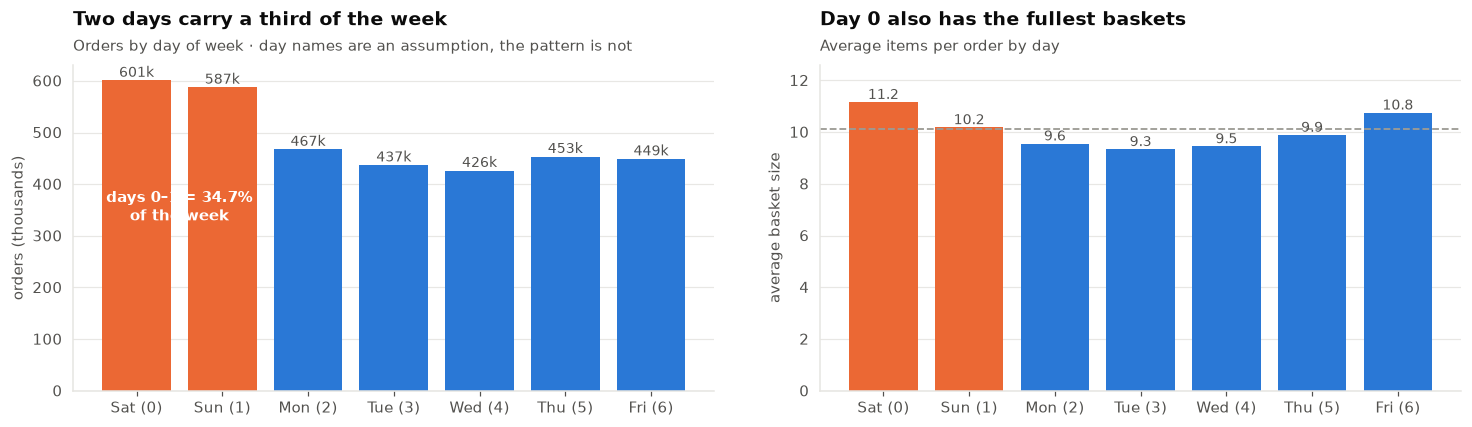

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.0))
cols = [ic.PALETTE["s2"] if i<=1 else ic.PALETTE["s1"] for i in bd.order_dow]
axes[0].bar(bd.label, bd.orders/1000, color=cols)
for i, v in enumerate(bd.orders/1000):
    axes[0].text(i, v+7, f"{v:.0f}k", ha="center", fontsize=9, color=ic.PALETTE["muted"])
axes[0].text(0.5, 330, "days 0–1 = 34.7%\nof the week", ha="center", fontsize=10,
             color="white", fontweight="600")
ic.finish(axes[0], "Two days carry a third of the week",
          "Orders by day of week · day names are an assumption, the pattern is not",
          "", "orders (thousands)")
axes[0].tick_params(axis="x", labelrotation=0)

axes[1].bar(bd.label, bd.avg_basket, color=cols)
axes[1].axhline(known.basket_size.mean(), color=ic.PALETTE["neutral"], ls="--", lw=1.2)
for i, v in enumerate(bd.avg_basket):
    axes[1].text(i, v+.12, f"{v:.1f}", ha="center", fontsize=9, color=ic.PALETTE["muted"])
ic.finish(axes[1], "Day 0 also has the fullest baskets",
          "Average items per order by day", "", "average basket size")
axes[1].set_ylim(0, 12.6)
fig.tight_layout(); ic.savefig(fig, "03_orders_by_dow"); plt.show()

  table  -> reports/tables/dow_hour_matrix.csv  (7 rows)


  figure -> reports/figures/03_dow_hour_heatmap.png


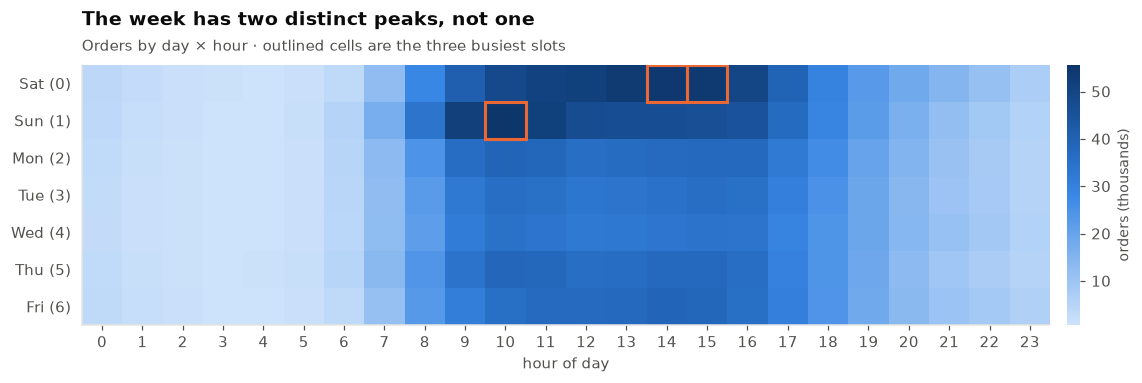

In [10]:
m = an.dow_hour_matrix(orders); ic.savetable(m, "dow_hour_matrix", index=True)
fig, ax = plt.subplots(figsize=(11.5, 3.6))
im = ax.imshow(m.values/1000, aspect="auto", cmap=ic.seq_cmap(), origin="upper")
ax.set_yticks(range(7)); ax.set_yticklabels(ic.DOW_LABELS)
ax.set_xticks(range(0,24,1)); ax.set_xticklabels(range(24))
cb = fig.colorbar(im, ax=ax, pad=.015); cb.set_label("orders (thousands)", color=ic.PALETTE["muted"], fontsize=9)
cb.outline.set_visible(False)
top = m.stack().sort_values(ascending=False).head(3)
for (d, h) in top.index:
    ax.add_patch(plt.Rectangle((h-.5, d-.5), 1, 1, fill=False, edgecolor=ic.PALETTE["s2"], lw=2))
ic.finish(ax, "The week has two distinct peaks, not one",
          "Orders by day × hour · outlined cells are the three busiest slots",
          "hour of day", "")
ax.grid(False)
fig.tight_layout(); ic.savefig(fig, "03_dow_hour_heatmap"); plt.show()

**Finding.** Day 0 (600,905 orders) and day 1 (587,478) carry **34.7%** of the week; the
quietest day, day 4, carries 12.5%. Peak-to-trough is only **1.41x** — a real rhythm but
a gentle one, which tells us capacity planning is driven more by the hour than by the day.

The heatmap shows the two peaks have **different shapes**. Day 0 peaks in the early
afternoon (13:00–15:00), day 1 peaks in the morning (09:00–11:00). Day 0 also has the
fullest baskets of the week (11.16 items vs 9.34 on day 3). So these are two different
shopping occasions two days running — an afternoon stock-up followed by a morning top-up —
and a single "weekend campaign" sent at one time would miss one of them.

## 3.5 Phase 6.3 — Days since previous order

*Question: how long do customers wait between orders, and does the wait change what they buy?*

In [11]:
bds = an.by_dspo(orders); ic.savetable(bds, "orders_by_days_since_prior")
display(bds[bds.days_since_prior_order.isin([0,1,3,7,14,21,30])].round(4))

  table  -> reports/tables/orders_by_days_since_prior.csv  (31 rows)


,days_since_prior_order,orders,avg_basket,items,reorders,reorder_rate,order_share
0,0.0,66562,6.9971,465742.0,345527.0,0.7419,0.0212
1,1.0,143727,6.6820,960381.0,593109.0,0.6176,0.0458
3,3.0,214681,8.9176,1914431.0,1279447.0,0.6683,0.0684
7,7.0,315335,11.3730,3586305.0,2488689.0,0.6939,0.1004
14,14.0,97580,11.0914,1082295.0,681029.0,0.6292,0.0311
21,21.0,43883,10.7953,473730.0,277581.0,0.5859,0.0140
30,30.0,346256,10.0426,3477322.0,1593164.0,0.4582,0.1103


  figure -> reports/figures/03_days_since_prior.png


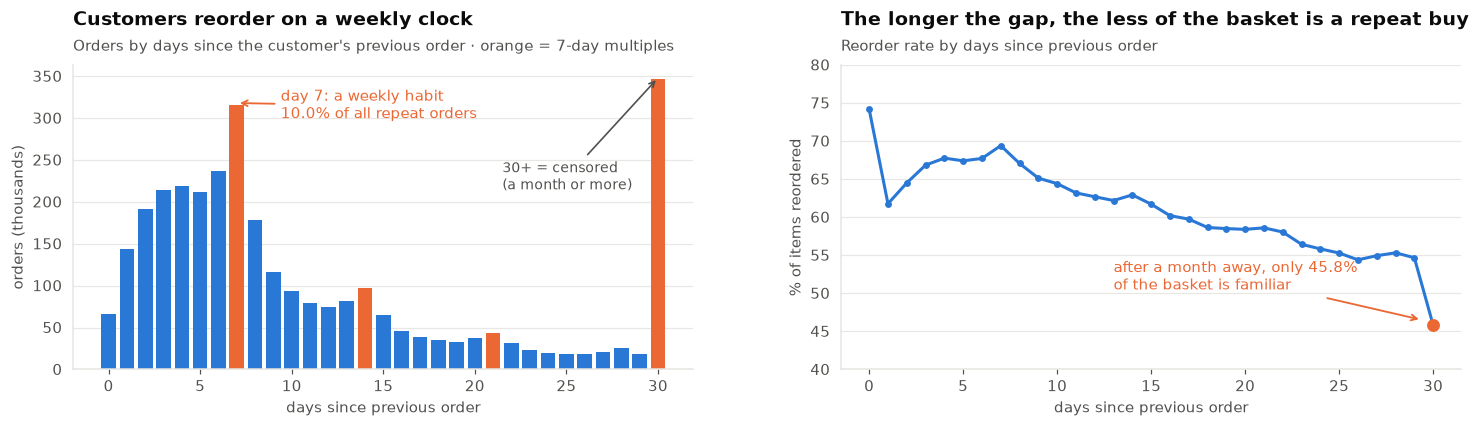

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.0))
cols = [ic.PALETTE["s2"] if d in (7,14,21,30) else ic.PALETTE["s1"] for d in bds.days_since_prior_order]
axes[0].bar(bds.days_since_prior_order, bds.orders/1000, color=cols)
axes[0].annotate("day 7: a weekly habit\n10.0% of all repeat orders",
                 xy=(7, 318), xytext=(9.4, 300), fontsize=9.5, color=ic.PALETTE["s2"],
                 arrowprops=dict(arrowstyle="->", color=ic.PALETTE["s2"], lw=1.2))
axes[0].annotate("30+ = censored\n(a month or more)", xy=(30, 348), xytext=(21.5, 215),
                 fontsize=9, color=ic.PALETTE["muted"],
                 arrowprops=dict(arrowstyle="->", color=ic.PALETTE["muted"], lw=1.1))
ic.finish(axes[0], "Customers reorder on a weekly clock",
          "Orders by days since the customer's previous order · orange = 7-day multiples",
          "days since previous order", "orders (thousands)")

axes[1].plot(bds.days_since_prior_order, bds.reorder_rate*100, color=ic.PALETTE["s1"], lw=2, marker="o", ms=3.5)
axes[1].scatter([30], [bds[bds.days_since_prior_order==30].reorder_rate.iat[0]*100],
                color=ic.PALETTE["s2"], s=55, zorder=5)
axes[1].annotate("after a month away, only 45.8%\nof the basket is familiar",
                 xy=(29.4, 46.5), xytext=(13, 50.5), fontsize=9.5, color=ic.PALETTE["s2"],
                 arrowprops=dict(arrowstyle="->", color=ic.PALETTE["s2"], lw=1.2))
ic.finish(axes[1], "The longer the gap, the less of the basket is a repeat buy",
          "Reorder rate by days since previous order", "days since previous order", "% of items reordered")
axes[1].set_ylim(40, 80)
fig.tight_layout(); ic.savefig(fig, "03_days_since_prior"); plt.show()

**Finding — the clearest behavioural signal in the dataset.**

* **50.9%** of repeat orders arrive within 7 days of the previous one.
* Day 7 is a visible spike: **10.0%** of repeat orders land exactly 7 days later, against
  7.5% at day 6 and 5.7% at day 8. Secondary bumps sit at 14, 21 and 30. Customers are
  running a **weekly shop**, and a sizeable group runs a fortnightly or monthly one.
* Reorder rate falls monotonically with the gap: **65.8%** for orders placed within 3 days,
  **48.0%** for those placed after 25+ days. Same-day orders are the most repetitive of all
  (74.2%) — those are forgotten-item top-ups.

**Business meaning.** The interval isn't just a retention metric, it predicts *what will be
in the basket*. A customer returning after a week wants their usual list; a customer
returning after a month has partly lost the habit and is rebuilding it. Those two need
different interventions, and the 7-day rhythm gives a natural, non-arbitrary trigger point
for a reminder.

## 3.6 Basket size

*Question: what does a typical order look like, and do big baskets behave differently?*

In [13]:
bsd = an.basket_size_dist(orders); ic.savetable(bsd, "basket_size_distribution")
display(bsd.round(4))

  table  -> reports/tables/basket_size_distribution.csv  (8 rows)


,bucket,orders,items,reorder_rate,order_share,item_share
0,1-3,573014,1197495.0,0.6498,0.1712,0.0354
1,4-5,467524,2107321.0,0.6102,0.1397,0.0623
2,6-10,1039954,8154089.0,0.5828,0.3108,0.2411
3,11-15,615724,7859486.0,0.5778,0.1840,0.2324
4,16-20,332018,5890114.0,0.5838,0.0992,0.1742
5,21-30,248821,6055869.0,0.5953,0.0744,0.1791
6,31-50,65785,2365065.0,0.6118,0.0197,0.0699
7,51+,3243,189667.0,0.6104,0.0010,0.0056


  figure -> reports/figures/03_basket_size.png


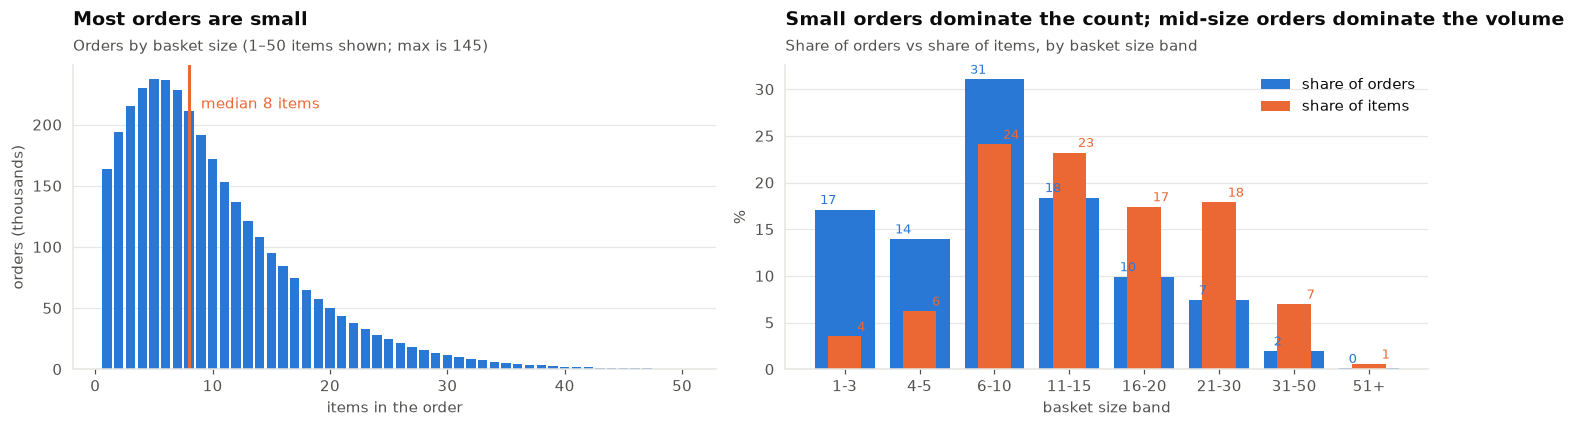

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.0))
h = known.basket_size.value_counts().sort_index()
h = h[h.index<=50]
axes[0].bar(h.index, h.values/1000, color=ic.PALETTE["s1"])
axes[0].axvline(known.basket_size.median(), color=ic.PALETTE["s2"], lw=2)
axes[0].text(known.basket_size.median()+1, h.max()/1000*.9, f"median {known.basket_size.median():.0f} items",
             color=ic.PALETTE["s2"], fontsize=9.5)
ic.finish(axes[0], "Most orders are small",
          "Orders by basket size (1–50 items shown; max is 145)", "items in the order", "orders (thousands)")

axes[1].bar(bsd.bucket.astype(str), bsd.order_share*100, color=ic.PALETTE["s1"], label="share of orders")
axes[1].bar(bsd.bucket.astype(str), bsd.item_share*100, color=ic.PALETTE["s2"], width=.45, label="share of items")
for i,(o,s) in enumerate(zip(bsd.order_share*100, bsd.item_share*100)):
    axes[1].text(i-.22, o+.6, f"{o:.0f}", fontsize=8.5, ha="center", color=ic.PALETTE["s1"])
    axes[1].text(i+.22, s+.6, f"{s:.0f}", fontsize=8.5, ha="center", color=ic.PALETTE["s2"])
axes[1].legend(loc="upper right")
ic.finish(axes[1], "Small orders dominate the count; mid-size orders dominate the volume",
          "Share of orders vs share of items, by basket size band", "basket size band", "%")
fig.tight_layout(); ic.savefig(fig, "03_basket_size"); plt.show()

**Finding.** The median order is **8 items**, the mean 10.1 — right-skewed, so the median
is the honest summary. **17.1%** of all orders contain 3 items or fewer, and 4.9% are a
single item. Those tiny orders are 17% of the order count but only **3.5%** of the units,
while 6–20 item orders are 59.4% of orders and **64.8%** of units.

The operational read: a large share of delivery capacity is consumed by baskets that carry
very little volume. Small baskets also have the *highest* reorder rate (65.0% for 1–3 item
orders vs 57.8% for 11–15) — they are forgotten-essentials top-ups, not exploratory shops.
That makes basket-building (a reminder of the customer's usual items at checkout) a more
promising lever than a minimum-order rule, which would simply suppress the habit.

## 3.7 Where the add-to-cart order points

*Question: the dataset records the sequence in which items entered the cart. Does position carry information?*

  table  -> reports/tables/reorder_by_cart_position.csv  (25 rows)
  figure -> reports/figures/03_cart_position.png


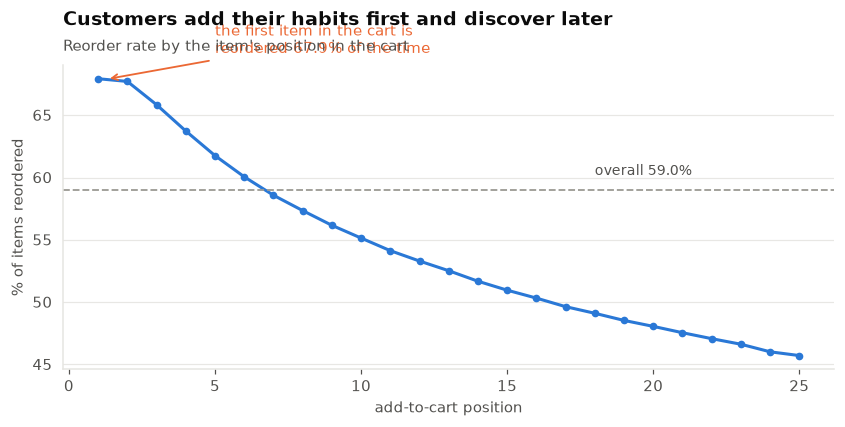

In [15]:
rc = an.reorder_by_cart_position(items, cap=25); ic.savetable(rc, "reorder_by_cart_position")
fig, ax = plt.subplots(figsize=(7.8, 4.0))
ax.plot(rc.add_to_cart_order, rc.reorder_rate*100, color=ic.PALETTE["s1"], lw=2, marker="o", ms=4)
ax.axhline(items.reordered.mean()*100, color=ic.PALETTE["neutral"], ls="--", lw=1.2)
ax.text(18, items.reordered.mean()*100+1.2, "overall 59.0%", color=ic.PALETTE["muted"], fontsize=9)
ax.annotate("the first item in the cart is\nreordered 67.9% of the time", xy=(1.3, 67.9),
            xytext=(5, 70), fontsize=9.5, color=ic.PALETTE["s2"],
            arrowprops=dict(arrowstyle="->", color=ic.PALETTE["s2"], lw=1.2))
ic.finish(ax, "Customers add their habits first and discover later",
          "Reorder rate by the item's position in the cart", "add-to-cart position", "% of items reordered")
fig.tight_layout(); ic.savefig(fig, "03_cart_position"); plt.show()

**Finding.** Reorder rate falls steadily with cart position: **67.9%** at position 1,
55.1% at position 10, **51.0%** at position 15. Shoppers front-load their routine
purchases and only then browse.

**Business meaning.** This is a direct design instruction. The early part of a session is
the customer executing a known list — the interface should make that as fast as possible
(a one-tap "usual items" list). Discovery and cross-sell belong *later* in the session,
once the habitual items are already in the basket. Putting recommendations on the first
screen competes with the task the customer actually came to do.

## 3.8 Phase 4 — Category KPIs (summary; detail in notebook 05)

In [16]:
dk = an.category_kpis(items, depts[["department_id","department","is_placeholder"]], "department")
dk["basket_penetration"] = dk.department_id.map(an.category_penetration(items, orders, "department"))
ic.savetable(dk, "department_kpis")
display(dk[["department","units","units_share","basket_penetration","reorder_rate","n_products","is_placeholder"]]
        .head(10).style.format({"units":"{:,.0f}","units_share":"{:.1%}","basket_penetration":"{:.1%}","reorder_rate":"{:.1%}"}).hide(axis="index"))

ak = an.category_kpis(items, aisles[["aisle_id","aisle","is_placeholder"]], "aisle")
ak["basket_penetration"] = ak.aisle_id.map(an.category_penetration(items, orders, "aisle"))
ic.savetable(ak, "aisle_kpis")
display(ak[["aisle","units","units_share","basket_penetration","reorder_rate"]].head(10)
        .style.format({"units":"{:,.0f}","units_share":"{:.1%}","basket_penetration":"{:.1%}","reorder_rate":"{:.1%}"}).hide(axis="index"))

  table  -> reports/tables/department_kpis.csv  (21 rows)


department,units,units_share,basket_penetration,reorder_rate,n_products,is_placeholder
produce,"9,888,378",29.2%,74.9%,65.1%,1679,False
dairy eggs,"5,631,067",16.7%,67.7%,67.0%,3441,False
snacks,"3,006,412",8.9%,43.3%,57.4%,6250,False
beverages,"2,804,175",8.3%,45.4%,65.4%,4353,False
frozen,"2,336,858",6.9%,36.8%,54.3%,3998,False
pantry,"1,956,819",5.8%,34.8%,34.7%,5359,False
bakery,"1,225,181",3.6%,27.4%,62.8%,1516,False
canned goods,"1,114,857",3.3%,21.2%,45.9%,2066,False
deli,"1,095,540",3.2%,24.0%,60.8%,1322,False
dry goods pasta,"905,340",2.7%,18.6%,46.2%,1856,False


  table  -> reports/tables/aisle_kpis.csv  (134 rows)


aisle,units,units_share,basket_penetration,reorder_rate
fresh fruits,"3,792,661",11.2%,55.7%,71.9%
fresh vegetables,"3,568,630",10.6%,44.4%,59.5%
packaged vegetables fruits,"1,843,806",5.5%,36.7%,63.9%
yogurt,"1,507,583",4.5%,26.3%,68.7%
packaged cheese,"1,021,462",3.0%,23.0%,58.6%
milk,"923,659",2.7%,24.4%,78.2%
water seltzer sparkling water,"878,150",2.6%,19.2%,73.0%
chips pretzels,"753,739",2.2%,16.8%,58.9%
soy lactosefree,"664,493",2.0%,17.0%,69.2%
bread,"608,469",1.8%,16.4%,67.1%


## 3.9 Phase 3/6 summary — what we know about *when*

| Question | Answer | Evidence |
|---|---|---|
| Busiest hour | 10:00 | 288,418 orders; 09:00–16:00 = 64.9% of all orders |
| Quietest hour | 03:00 | 5,474 orders; 00:00–05:00 = 1.8% |
| Busiest day | day 0, then day 1 | 600,905 + 587,478 = 34.7% of the week |
| Quietest day | day 4 | 426,339 orders; peak:trough only 1.41x |
| Do the two peak days behave the same? | **No** | day 0 peaks 13:00–15:00 with 11.2-item baskets; day 1 peaks 09:00–11:00 with 10.2 |
| Typical gap between orders | 7 days | 50.9% of repeat orders within a week; a clear spike exactly at day 7 |
| Does the gap change the basket? | **Yes, strongly** | reorder rate 65.8% at ≤3 days → 48.0% at 25+ days |
| Biggest baskets | 21:00–23:00 and day 0 | 10.9–11.0 items vs 10.1 overall |

Carried into the recommendations: the **weekly clock** (a non-arbitrary reminder trigger),
the **two-shaped weekend** (one campaign time will miss half of it), and the finding that
**the busiest hour is not the biggest-basket hour**.